In [23]:
import pandas as pd

In [24]:
df=pd.read_csv('/content/swiggy.csv')  #Read the Swiggy document

In [25]:
df.head()

,id,name,city,rating,rating_count,cost,cuisine,lic_no,link,address,menu
0,567335,AB FOODS POINT,Abohar,--,Too Few Ratings,₹ 200,"Beverages,Pizzas",22122652000138,https://www.swiggy.com/restaurants/ab-foods-po...,"AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Menu/567335.json
1,531342,Janta Sweet House,Abohar,4.4,50+ ratings,₹ 200,"Sweets,Bakery",12117201000112,https://www.swiggy.com/restaurants/janta-sweet...,"Janta Sweet House, Bazar No.9, Circullar Road,...",Menu/531342.json
2,158203,theka coffee desi,Abohar,3.8,100+ ratings,₹ 100,Beverages,22121652000190,https://www.swiggy.com/restaurants/theka-coffe...,"theka coffee desi, sahtiya sadan road city",Menu/158203.json
3,187912,Singh Hut,Abohar,3.7,20+ ratings,₹ 250,"Fast Food,Indian",22119652000167,https://www.swiggy.com/restaurants/singh-hut-n...,"Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Menu/187912.json
4,543530,GRILL MASTERS,Abohar,--,Too Few Ratings,₹ 250,"Italian-American,Fast Food",12122201000053,https://www.swiggy.com/restaurants/grill-maste...,"GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Menu/543530.json


In [26]:
df.columns

Index(['id', 'name', 'city', 'rating', 'rating_count', 'cost', 'cuisine',
       'lic_no', 'link', 'address', 'menu'],
      dtype='object')

In [27]:
#Remove unwanted columns
df.drop(columns=['lic_no', 'link', 'menu'],inplace=True,axis=1)

In [28]:
df.head()

,id,name,city,rating,rating_count,cost,cuisine,address
0,567335,AB FOODS POINT,Abohar,--,Too Few Ratings,₹ 200,"Beverages,Pizzas","AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI..."
1,531342,Janta Sweet House,Abohar,4.4,50+ ratings,₹ 200,"Sweets,Bakery","Janta Sweet House, Bazar No.9, Circullar Road,..."
2,158203,theka coffee desi,Abohar,3.8,100+ ratings,₹ 100,Beverages,"theka coffee desi, sahtiya sadan road city"
3,187912,Singh Hut,Abohar,3.7,20+ ratings,₹ 250,"Fast Food,Indian","Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR"
4,543530,GRILL MASTERS,Abohar,--,Too Few Ratings,₹ 250,"Italian-American,Fast Food","GRILL MASTERS, ADA Heights, Abohar - Hanumanga..."


In [29]:
df.duplicated().sum() #find any duplicate rows found

np.int64(0)

In [30]:
df['id'].duplicated().sum() #Find any duplicate 'id'

np.int64(0)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148541 entries, 0 to 148540
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            148541 non-null  int64 
 1   name          148455 non-null  object
 2   city          148541 non-null  object
 3   rating        148455 non-null  object
 4   rating_count  148455 non-null  object
 5   cost          148410 non-null  object
 6   cuisine       148442 non-null  object
 7   address       148455 non-null  object
dtypes: int64(1), object(7)
memory usage: 9.1+ MB


In [32]:
#remove ₹ symbol and space from cost column
df['cost'] = df['cost'].str.replace('₹','').str.replace(' ','')


In [33]:
#Find unique values of rating_count
df['rating_count'].unique()

array(['Too Few Ratings', '50+ ratings', '100+ ratings', '20+ ratings',
       '500+ ratings', '1K+ ratings', '5K+ ratings', nan, '10K+ ratings'],
      dtype=object)

In [34]:
#Change the necessary correction of rating_count
df['rating_count']=df['rating_count'].str.replace('+','').str.replace('k','000').str.replace(' ','').str.replace('ratings','').str.replace('K','000').str.replace('Too Few Ratings','')

In [35]:
df['rating_count'].unique()

array(['TooFewRatings', '50', '100', '20', '500', '1000', '5000', nan,
       '10000'], dtype=object)

In [36]:
df['rating_count']=df['rating_count'].str.replace('TooFewRatings','')

In [37]:
#Find unique values of rating_count
df['rating_count'].unique()

array(['', '50', '100', '20', '500', '1000', '5000', nan, '10000'],
      dtype=object)

In [38]:
#Convert numeric values from object to numeric
df['rating']=pd.to_numeric(df['rating'],errors='coerce')
df['cost']=pd.to_numeric(df['cost'],errors='coerce')
df['rating_count']=pd.to_numeric(df['rating_count'],errors='coerce')

In [39]:
df.columns

Index(['id', 'name', 'city', 'rating', 'rating_count', 'cost', 'cuisine',
       'address'],
      dtype='object')

In [40]:
#find the null values column wise
column_name=['id', 'name', 'city', 'rating', 'rating_count', 'cost', 'cuisine','address']
for i in column_name:
  null_count=df[i].isnull().sum()
  print(f"{i}:{null_count}")

id:0
name:86
city:0
rating:87100
rating_count:87100
cost:131
cuisine:99
address:86


In [41]:
#Find the null rows in name,rating,rating_count,address
null_rows = df[df[['name', 'rating', 'rating_count','address']].isnull().all(axis=1)]
null_rows.head()
null_rows.shape

(86, 8)

In [42]:
df.drop(null_rows.index,inplace=True) #null_rows dropped

In [43]:
#find the null values column wise after removing the null_values
column_name=['id', 'name', 'city', 'rating', 'rating_count', 'cost', 'cuisine','address']
for i in column_name:
  null_count=df[i].isnull().sum()
  print(f"{i}:{null_count}")

id:0
name:0
city:0
rating:87014
rating_count:87014
cost:45
cuisine:13
address:0


In [44]:
#Find the null rows in rating_count and cost
null_rows2 = df[df[['cost', 'cuisine']].isnull().any(axis=1)]
null_rows2.shape


(57, 8)

In [45]:
#Rows dropped if cost and rating_count are nan
df.drop(null_rows2.index,inplace=True)

In [46]:
#find the null values column wise after removing the null_values
column_name=['id', 'name', 'city', 'rating', 'rating_count', 'cost', 'cuisine','address']
for i in column_name:
  null_count=df[i].isnull().sum()
  print(f"{i}:{null_count}")

id:0
name:0
city:0
rating:86977
rating_count:86977
cost:0
cuisine:0
address:0


In [47]:
# calculate minimum of rating count

min_rating_count = df['rating_count'].min(skipna=True)
min_rating_count

20.0

In [48]:
df['rating_count'].fillna(min_rating_count,inplace=True)

<ipython-input-48-d0e86665bfeb>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating_count'].fillna(min_rating_count,inplace=True)


In [49]:
df['rating_count'].isnull().sum()

np.int64(0)

In [50]:
df['rating'].fillna(df.groupby('rating_count')['rating'].transform('mean'), inplace=True)

<ipython-input-50-c02315a1677c>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['rating'].fillna(df.groupby('rating_count')['rating'].transform('mean'), inplace=True)


In [51]:
df['rating'].isnull().sum()

np.int64(0)

In [52]:
#Split city names and create new city as main_city

def extract_main_city(city_string):
    cities = city_string.split(',')
    if len(cities) > 1:
        return cities[1].strip()  # Extract the second city
    else:
        return cities[0].strip()  # Return the only city if only one exists

# Apply the function to create the 'main_city' column
df['main_city'] = df['city'].apply(extract_main_city)
df['main_city']

,main_city
0,Abohar
1,Abohar
2,Abohar
3,Abohar
4,Abohar
...,...
148536,Yavatmal
148537,Yavatmal
148538,Yavatmal
148539,Yavatmal


In [53]:
#Remove second city name

def city(city_string):
    cities = city_string.split(',')
    return cities[0].strip()  # Return the only city if only one exists

# Apply the function to create the 'main_city' column
df['city'] = df['city'].apply(city)
df['city']

,city
0,Abohar
1,Abohar
2,Abohar
3,Abohar
4,Abohar
...,...
148536,Yavatmal
148537,Yavatmal
148538,Yavatmal
148539,Yavatmal


In [54]:
df

,id,name,city,rating,rating_count,cost,cuisine,address,main_city
0,567335,AB FOODS POINT,Abohar,3.756672,20.0,200.0,"Beverages,Pizzas","AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI...",Abohar
1,531342,Janta Sweet House,Abohar,4.400000,50.0,200.0,"Sweets,Bakery","Janta Sweet House, Bazar No.9, Circullar Road,...",Abohar
2,158203,theka coffee desi,Abohar,3.800000,100.0,100.0,Beverages,"theka coffee desi, sahtiya sadan road city",Abohar
3,187912,Singh Hut,Abohar,3.700000,20.0,250.0,"Fast Food,Indian","Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR",Abohar
4,543530,GRILL MASTERS,Abohar,3.756672,20.0,250.0,"Italian-American,Fast Food","GRILL MASTERS, ADA Heights, Abohar - Hanumanga...",Abohar
...,...,...,...,...,...,...,...,...,...
148536,553122,The Food Delight,Yavatmal,3.756672,20.0,200.0,"Fast Food,Snacks","The Food Delight, 94MC+X35, New Singhania Naga...",Yavatmal
148537,562647,MAITRI FOODS & BEVERAGES,Yavatmal,3.756672,20.0,300.0,Pizzas,"MAITRI FOODS & BEVERAGES, POLIC MITRYA SOCIETY...",Yavatmal
148538,559435,Cafe Bella Ciao,Yavatmal,3.756672,20.0,300.0,"Fast Food,Snacks","Cafe Bella Ciao, SHOP NO 2 NEMANI MARKET SBI S...",Yavatmal
148539,418989,GRILL ZILLA,Yavatmal,3.756672,20.0,250.0,Continental,"GRILL ZILLA, SHO NO 2/6, POSTEL GROUND CHOWPAT...",Yavatmal


In [ ]:
#Save the dataset as csv
df.to_csv('cleaned_data.csv')

In [12]:
import pandas as pd
df2=pd.read_csv('/content/cleaned_data.csv')
df2=df2.drop('Unnamed: 0',axis=1)

In [13]:
df2.head()

,id,name,city,rating,rating_count,cost,cuisine,address
0,567335,AB FOODS POINT,Abohar,3.756672,20.0,200.0,"Beverages,Pizzas","AB FOODS POINT, NEAR RISHI NARANG DENTAL CLINI..."
1,531342,Janta Sweet House,Abohar,4.400000,50.0,200.0,"Sweets,Bakery","Janta Sweet House, Bazar No.9, Circullar Road,..."
2,158203,theka coffee desi,Abohar,3.800000,100.0,100.0,Beverages,"theka coffee desi, sahtiya sadan road city"
3,187912,Singh Hut,Abohar,3.700000,20.0,250.0,"Fast Food,Indian","Singh Hut, CIRCULAR ROAD NEAR NEHRU PARK ABOHAR"
4,543530,GRILL MASTERS,Abohar,3.756672,20.0,250.0,"Italian-American,Fast Food","GRILL MASTERS, ADA Heights, Abohar - Hanumanga..."


In [14]:
#Apply MinMax Scaler for Numerical Values
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled=scaler.fit_transform(df2[['rating','cost']])
df_scaled = pd.DataFrame(scaled, columns=['rating', 'cost'])
with open('minmax_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [59]:
df_scaled.head()

,rating,cost
0,0.689168,0.000663
1,0.850000,0.000663
2,0.700000,0.000330
3,0.675000,0.000829
4,0.689168,0.000829


In [70]:
#Apply one hot encoding for categical features
from sklearn.preprocessing import OneHotEncoder
categorical_features=['city','cuisine']
encoder=OneHotEncoder(sparse_output=False)
encoded=encoder.fit_transform(df2[categorical_features])
df_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_features))
with open('Encoded_data.pkl', 'wb') as f:
    pickle.dump(encoder, f)

In [ ]:
df_encoded.shape

(148398, 2952)

In [ ]:
# Combine processed features
import pandas as pd
encoded_data = pd.concat([df_scaled,df_encoded], axis=1)

In [ ]:
#Save the Encoded dataset as csv
encoded_data.to_csv('Encoded_data.csv')

KeyboardInterrupt: 

In [ ]:
# Save as Pickle
import pickle
with open('Encoded_data.pkl', 'wb') as f:
    pickle.dump(encoded_data, f)

In [ ]:
# Load the saved Pickle file
with open('Encoded_data.pkl', 'rb') as encoded_data:
    encoded_data = pickle.load(encoded_data)

In [3]:
import pandas as pd
features=pd.read_csv('/content/Encoded_data.csv')
features=features.drop('Unnamed: 0',axis=1)

In [4]:
features.shape

(148398, 2954)

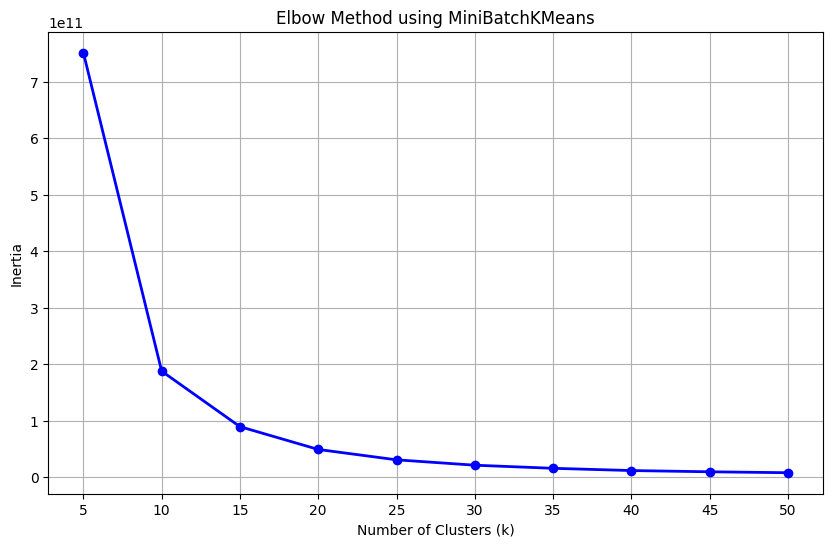

In [ ]:
#Use Elbo method to find optimal K
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.utils import resample

features_sample = resample(encoded_data, n_samples=10000, random_state=42)

inertia = []
k_range = range(5, 51, 5)
for k in k_range:
    mb_kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=2048)
    mb_kmeans.fit(features_sample)
    inertia.append(mb_kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-', linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method using MiniBatchKMeans')
plt.grid(True)
plt.xticks(k_range)
plt.show()

In [35]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Project4/cleaned_data.csv')
df = df.drop(columns=['Unnamed: 0'], errors='ignore')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
df.columns

Index(['id', 'name', 'city', 'rating', 'rating_count', 'cost', 'cuisine',
       'address'],
      dtype='object')

In [ ]:
features=pd.read_csv('/content/drive/MyDrive/Project4/Encoded_data.csv')
features=features.drop('Unnamed: 0',axis=1)
features.shape

In [17]:
features = pd.read_pickle('/content/drive/MyDrive/Project4/Encoded_data.pkl')
features=features.drop(columns=['Unnamed: 0'], errors='ignore')
features.shape

(148398, 2954)

In [18]:
import pandas as pd
import pickle
from sklearn.decomposition import IncrementalPCA

ipca = IncrementalPCA(n_components=100, batch_size=1000)
features_pca = ipca.fit_transform(features)

# Convert PCA result to a DataFrame
pca_columns = [f'PC{i+1}' for i in range(features_pca.shape[1])]
features_pca_df = pd.DataFrame(features_pca, columns=pca_columns)

# Save the IncrementalPCA transformer
with open('incremental_pca_transformer.pkl', 'wb') as pca_file:
    pickle.dump(ipca, pca_file)


In [21]:
features_pca_df.to_csv('features_pca_df.csv')

In [32]:
import pandas as pd
from google.colab import drive
features_pca = pd.read_csv('/content/drive/MyDrive/Project4/features_pca_df.csv')
features_pca = features_pca.drop(columns=['Unnamed: 0'], errors='ignore')

In [36]:
import pandas as pd
import pickle
from sklearn.cluster import KMeans

# Fit the KMeans model on PCA-transformed features
optimal_k = 10
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(features_pca)

# Add cluster labels to the original DataFrame
df['Cluster'] = cluster_labels

# Save KMeans model and PCA transformer as pickle files
with open('kmeans_model.pkl', 'wb') as km_file:
    pickle.dump(kmeans, km_file)




# Save clustered dataset
df.to_csv('clustered_data.csv', index=False)


In [41]:
import pickle
import pandas as pd
from google.colab import drive
from sklearn.preprocessing import OneHotEncoder
#drive.mount('/content/drive')

#Load Pickle Files
with open('/content/drive/MyDrive/Project4/minmax_scaler1.pkl', 'rb') as f:
    minmax_scaler = pickle.load(f)
with open('/content/drive/MyDrive/Project4/Encoded_data1.pkl', 'rb') as f:
    onehot_encoder = pickle.load(f)
with open('/content/drive/MyDrive/Project4/incremental_pca_transformer.pkl', 'rb') as f:
    incremental_pca = pickle.load(f)
with open('/content/drive/MyDrive/Project4/kmeans_model.pkl', 'rb') as f:
    kmeans_model = pickle.load(f)

df=pd.read_csv('/content/drive/MyDrive/Project4/clustered_data.csv')

#User Input
city=input("Enter City: ")
rating=float(input("Enter Rating: "))
cost=int(input("Enter Cost: "))
cuisine=input("Enter Cuisine: ")
new_data = {
    'city': city,
    'rating': rating,
    'cost': cost,
    'cuisine': cuisine
}
input_df = pd.DataFrame([new_data])

# Separate columns
categorical_cols = ['city', 'cuisine']
numerical_cols = ['rating', 'cost']

# OneHot encoder for categorical data
input_cat_encoded = onehot_encoder.transform(input_df[categorical_cols])
input_cat_encoded_df = pd.DataFrame(input_cat_encoded, columns=onehot_encoder.get_feature_names_out(categorical_cols))

# MinMax Scaler for numerical data
input_num_scaled = minmax_scaler.transform(input_df[numerical_cols])
input_num_scaled_df = pd.DataFrame(input_num_scaled, columns=numerical_cols)

# Combine all features
input_combined = pd.concat([input_num_scaled_df,input_cat_encoded_df], axis=1)

#Apply Incremental PCA
input_pca = incremental_pca.transform(input_combined)

#Predict Cluster
predicted_cluster = kmeans_model.predict(input_pca)
print(f"Predicted Cluster: {predicted_cluster[0]}")

# Step 4: Filter and display rows from df in the same cluster
matching_rows = df[df['Cluster'] == predicted_cluster[0]]

print("\n🎯 Matching rows from dataset with same cluster:")
display(matching_rows.head(10))  # Show top 10 matches

Enter City: Abohar
Enter Rating: 4
Enter Cost: 200
Enter Cuisine: North Indian
Predicted Cluster: 7

🎯 Matching rows from dataset with same cluster:


,id,name,city,rating,rating_count,cost,cuisine,address,Cluster
103278,184351,Shivi's Chats Hub,Mandya,3.900000,100.0,100.0,Indian,"Shivi's Chats Hub, 3RD CROSS, NEAR RAMANA HOTE...",7
103279,157868,The Snacks Cafe,Mandya,3.756672,20.0,200.0,Chinese,"The Snacks Cafe, Double road Ashok Nagar Mandya",7
103280,412195,SHREE MAHALAKSHMI SWEETS,Mandya,3.900000,50.0,100.0,Sweets,"SHREE MAHALAKSHMI SWEETS, VV Road Manyda,karna...",7
103281,358203,Taj Palace,Mandya,3.800000,100.0,200.0,"North Indian,Indian","Taj Palace, B M Road, Government Boys College,...",7
103282,184241,Hotel Sarovara Family Restaurant,Mandya,3.500000,20.0,100.0,"South Indian,North Indian","Hotel Sarovara Family Restaurant, 3rd cross, ...",7
103283,157871,New SLV Cafe (GOLI),Mandya,3.500000,20.0,200.0,"Snacks,Chinese","New SLV Cafe (GOLI), 2nd Cross Vidyanagar Near...",7
103284,184350,The Best food Shop,Mandya,3.200000,50.0,100.0,"Snacks,Chinese","The Best food Shop, 1569/A, 2ND CROSS, VIDYA N...",7
103285,341002,Domhouse Pizza,Mandya,3.756672,20.0,250.0,"Snacks,Chinese","Domhouse Pizza, Vidya nagar 2nd cross, mandya ...",7
103286,353654,Polar Bear,Mandya,4.100000,50.0,350.0,"Ice Cream,Desserts","Polar Bear, 100 ft Road Hosahalli Circle Ashok...",7
103287,157873,MVG Bakery &Sweets-VV Road,Mandya,4.100000,50.0,200.0,"Snacks,Desserts","MVG Bakery &Sweets-VV Road, VV road ashoka nag...",7


In [43]:
!pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.6 MB/s eta 0:00:00


In [45]:
!pip install pyngrok

In [57]:
%%writefile app.py
import streamlit as st
import pandas as pd
import pickle

# Load Pickle Files
@st.cache_resource
def load_models():
    with open('/content/drive/MyDrive/Project4/minmax_scaler1.pkl', 'rb') as f:
        minmax_scaler = pickle.load(f)
    with open('/content/drive/MyDrive/Project4/Encoded_data1.pkl', 'rb') as f:
        onehot_encoder = pickle.load(f)
    with open('/content/drive/MyDrive/Project4/incremental_pca_transformer.pkl', 'rb') as f:
        incremental_pca = pickle.load(f)
    with open('/content/drive/MyDrive/Project4/kmeans_model.pkl', 'rb') as f:
        kmeans_model = pickle.load(f)
    return minmax_scaler, onehot_encoder, incremental_pca, kmeans_model

# Load Dataset
@st.cache_data
def load_data():
    return pd.read_csv('/content/drive/MyDrive/Project4/clustered_data.csv')

# App Title
st.title("🍽️ Swiggy’s Restaurant Recommendation System")

# User Inputs
city = st.text_input("Enter City")
rating = st.number_input("Enter Rating", min_value=0.0, max_value=5.0, step=0.5)
cost = st.number_input("Enter Cost", min_value=0,step=50)
cuisine = st.text_input("Enter Cuisine")

if st.button("Predict Cluster"):
    filled_inputs = sum([bool(city), rating > 0.0, cost > 0, bool(cuisine)])
    if filled_inputs < 2:
        st.warning("⚠️ Please provide at least two input fields.")
        st.stop()

    # Load models and data
    minmax_scaler, onehot_encoder, incremental_pca, kmeans_model = load_models()
    df = load_data()

    # Prepare input data
    new_data = pd.DataFrame([{
        'city': city.title(),
        'rating': rating,
        'cost': cost,
        'cuisine': cuisine.title()
    }])

    categorical_cols = ['city', 'cuisine']
    numerical_cols = ['rating', 'cost']

    try:
        # Encode and scale
        input_cat_encoded = onehot_encoder.transform(new_data[categorical_cols])
        input_cat_encoded_df = pd.DataFrame(input_cat_encoded, columns=onehot_encoder.get_feature_names_out(categorical_cols))

        input_num_scaled = minmax_scaler.transform(new_data[numerical_cols])
        input_num_scaled_df = pd.DataFrame(input_num_scaled, columns=numerical_cols)

        input_combined = pd.concat([input_num_scaled_df, input_cat_encoded_df], axis=1)

        # PCA and predict
        input_pca = incremental_pca.transform(input_combined)
        predicted_cluster = kmeans_model.predict(input_pca)[0]

        st.success(f"✅ Predicted Cluster: {predicted_cluster}")

        # Filter and display matching restaurants
        matching_rows = df[df['Cluster'] == predicted_cluster]
        st.subheader("🔍 Top Matches from Dataset")
        st.dataframe(matching_rows[['name', 'address']].head(10).reset_index(drop=True))

    except Exception as e:
        st.error(f"🚫 Error during prediction: {e}")


Overwriting app.py


In [58]:
import streamlit as st
from pyngrok import ngrok
from google.colab import userdata

auth_token=userdata.get('auth_token')

# Terminate any existing ngrok processes
!pkill -f ngrok

ngrok.set_auth_token(auth_token)
port = 8501

# Start Streamlit in the background
!streamlit run app.py &>/dev/null&

# Connect ngrok to the Streamlit port
public_url = ngrok.connect(port)
print("Streamlit App is live at:", public_url)

Streamlit App is live at: NgrokTunnel: "https://d1e6-35-231-248-206.ngrok-free.app" -> "http://localhost:8501"
